# Dynamic Programming (Week 2)

## Baseline Functions

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
import time


####################### gridworld environments #######################
class GridWorldOriginal(gym.Env):
    """4x4 GridWorld with terminal states at corners."""
    def __init__(self):
        self.size = 4
        self.nS = self.size * self.size  # 16 states
        self.nA = 4  # up, right, down, left
        
        # Terminal states
        self.terminals = [0, 15]
        
        # Transition dynamics: P[s][a] = [(prob, next_state, reward, done), ...]
        self.P = self._build_transitions()
    
    def _build_transitions(self):
        """Build P(s',r|s,a) for all s,a."""
        P = {}
        for s in range(self.nS):
            P[s] = {a: [] for a in range(self.nA)}
            
            if s in self.terminals:
                # Terminal: all actions lead to self with 0 reward
                for a in range(self.nA):
                    P[s][a] = [(1.0, s, 0, True)]
            else:
                # Non-terminal: compute next state for each action
                row, col = s // self.size, s % self.size
                
                # Action effects: [up, right, down, left]
                deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]
                
                for a in range(self.nA):
                    dr, dc = deltas[a]
                    next_row = max(0, min(self.size - 1, row + dr))
                    next_col = max(0, min(self.size - 1, col + dc))
                    next_s = next_row * self.size + next_col
                    
                    reward = -1  # Cost per step
                    done = next_s in self.terminals
                    
                    P[s][a] = [(1.0, next_s, reward, done)]
        
        return P

# custom stochastic gridworld environment
class CustomGridWorld(gym.Env):
    def __init__(self, size=5, stochasticity=0.0):
        self.size = size
        self.nS = size * size
        self.nA = 4
        self.stochasticity = stochasticity # e.g., 0.2 means 20% chance of failing
        self.terminals = [0, self.nS - 1]
        self.P = self._build_transitions()

    def _build_transitions(self):
        P = {}
        deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)] # Up, Right, Down, Left
        
        for s in range(self.nS):
            P[s] = {a: [] for a in range(self.nA)}
            if s in self.terminals:
                for a in range(self.nA):
                    P[s][a] = [(1.0, s, 0, True)]
                continue
            
            row, col = s // self.size, s % self.size
            
            for a in range(self.nA):
                # Intentional action
                next_s = self._get_next_state(row, col, deltas[a])
                
                if self.stochasticity > 0:
                    # 80% success, 10% left-perp, 10% right-perp
                    prob_main = 1 - self.stochasticity
                    prob_side = self.stochasticity / 2
                    
                    # Logic for perpendicular actions (a-1 and a+1)
                    P[s][a].append((prob_main, next_s, -1, next_s in self.terminals)) # fixed index out of range error
                    
                    # Left perpendicular
                    s_left = self._get_next_state(row, col, deltas[(a-1)%4])
                    P[s][a].append((prob_side, s_left, -1, s_left in self.terminals))
                    
                    # Right perpendicular
                    s_right = self._get_next_state(row, col, deltas[(a+1)%4])
                    P[s][a].append((prob_side, s_right, -1, s_right in self.terminals))
                else:
                    P[s][a] = [(1.0, next_s, -1, next_s in self.terminals)]
        return P

    def _get_next_state(self, r, c, delta):
        nr = max(0, min(self.size - 1, r + delta[0]))
        nc = max(0, min(self.size - 1, c + delta[1]))
        return nr * self.size + nc

####################### Improvement & Evaluation #######################
# Policy Evaluation
def policy_evaluation(env, policy, gamma=0.9, theta=1e-6):
    """
    Evaluate a policy in an environment with known dynamics.
    
    Args:
        env: GridWorld with transition dynamics P
        policy: Array of shape (nS, nA) with policy[s, a] = π(a|s)
        gamma: Discount factor
        theta: Convergence threshold
    
    Returns:
        V: State-value function (array of shape (nS,))
    """
    V = np.zeros(env.nS)
    
    while True:
        delta = 0
        
        # Sweep through all states
        for s in range(env.nS):
            v = V[s]  # Old value
            
            # Bellman update: V(s) = Σ_a π(a|s) * Σ_{s',r} P(s',r|s,a) * [r + γ*V(s')]
            new_value = 0
            for a in range(env.nA):
                for prob, next_s, reward, done in env.P[s][a]:
                    next_value = 0 if done else V[next_s]
                    new_value += policy[s, a] * prob * (reward + gamma * next_value)
            
            V[s] = new_value
            delta = max(delta, abs(v - V[s]))
        
        # Check convergence
        if delta < theta:
            break
    
    return V

# Policy Improvement - FIXED
def policy_improvement(env, V, old_policy, gamma=0.99):
    '''Iteratively improves policy, updated for numerical stability.'''
    policy = np.zeros((env.nS, env.nA))
    policy_stable = True
    
    for s in range(env.nS):
        q_values = np.zeros(env.nA)
        for a in range(env.nA):
            for prob, next_s, reward, done in env.P[s][a]:
                # If next_s is terminal, its future value contribution is 0
                q_values[a] += prob * (reward + gamma * V[next_s] * (1 - done))
        
        best_action = np.argmax(q_values)
        old_action = np.argmax(old_policy[s])
        
        if q_values[best_action] > q_values[old_action]:
            policy_stable = False
            
        policy[s, best_action] = 1.0
        
    return policy, policy_stable

def policy_iteration(env, gamma=0.99, theta=1e-8):
    # Initialize deterministic policy
    try:
        policy = np.zeros((env.nS, env.nA))
    except AttributeError: # handling FrozenLake
        env.nS = env.observation_space.n
        env.nA = env.action_space.n
        policy = np.zeros((env.nS, env.nA))
        
    policy[:, 0] = 1.0 # Start by always going Up
    
    V = np.zeros(env.nS)
    iters = 0
    
    while True:
        # policy evaluation and improvement; 
        V = policy_evaluation(env, policy, gamma, theta)
        new_policy, stable = policy_improvement(env, V, policy, gamma)
        
        iters += 1
        policy = new_policy
        
        if stable or iters > 100: # Safety break
            break
            
    return policy, V, iters

# Value Iteration Implementation (policy evaluation + improvement in one step)
def value_iteration(env, gamma=0.9, theta=1e-6):
    """Value iteration algorithm."""
    V = np.zeros(env.nS)
    
    while True:
        delta = 0
        
        # Sweep through all states
        for s in range(env.nS):
            v = V[s]
            
            # Bellman optimality update: V(s) = max_a Σ P(s',r|s,a) * [r + γ*V(s')]
            q_values = np.zeros(env.nA)
            for a in range(env.nA):
                for prob, next_s, reward, done in env.P[s][a]:
                    next_value = 0 if done else V[next_s]
                    q_values[a] += prob * (reward + gamma * next_value)
            
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))
        
        if delta < theta:
            break
    
    # Extract greedy policy
    policy = np.zeros((env.nS, env.nA))
    for s in range(env.nS):
        q_values = np.zeros(env.nA)
        for a in range(env.nA):
            for prob, next_s, reward, done in env.P[s][a]:
                next_value = 0 if done else V[next_s]
                q_values[a] += prob * (reward + gamma * next_value)
        best_action = np.argmax(q_values)
        policy[s, best_action] = 1.0
    
    return policy, V




#################### analysis functions ####################
def plot_results(pi_data, vi_data, env):
    '''Plots heatmap and quiver.'''
    # unpack input tuples
    policy_pi, V_pi = pi_data
    policy_vi, V_vi = vi_data
    
    
    if (env == lake_env) or (env == lake_sticky):
        env_size = int(np.sqrt(env.observation_space.n))
    else:
        env_size = env.size
    if "FrozenLake" in str(env):
        title_env = 'FrozenLake'
    elif hasattr(env, 'stochasticity') and env.stochasticity > 0:
        title_env = 'Custom Stochastic GridWorld'
    else:
        title_env = 'Baseline GridWorld'

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # mapping type of evaluation
    plot_configs = [
        (V_pi, policy_pi, "Policy Improvement", axes[0]),
        (V_vi, policy_vi, "Value Iteration", axes[1])
    ]
    action_to_uv = {0: (0, 1), 1: (1, 0), 2: (0, -1), 3: (-1, 0)}

    # generate plots
    for V, policy, label, ax_row in plot_configs:
        V_grid = V.reshape(env_size, env_size)
        
        # heatmap
        im = ax_row[0].imshow(V_grid, cmap='viridis')
        ax_row[0].set_title(f"{label}: States")
        fig.colorbar(im, ax=ax_row[0])

        # policy quiver
        u = np.zeros(V_grid.shape)
        v = np.zeros(V_grid.shape)
        for s in range(len(policy)):
            if s in [0, len(policy)-1]: continue  # check for terminals
            
            r, c = s // env_size, s % env_size
            action = np.argmax(policy[s])
            du, dv = action_to_uv[action]
            u[r, c] = du
            v[r, c] = dv

        ax_row[1].quiver(np.arange(env_size), np.arange(env_size)[::-1], u, v, 
                         scale=1.2, units='xy', color='red', pivot='mid')
        ax_row[1].set_title(f"{label}: Optimal Policy")
        ax_row[1].set_xticks(range(env_size))
        ax_row[1].set_yticks(range(env_size))
        ax_row[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if "FrozenLake" in str(env): 
        plt.savefig('lake_results.png', dpi=300)
    plt.show()

def analyze_convergence(env, verbose=True, save_plot=False):
    '''Plots convergence vs iterations and time.'''
    ### iterate through value iterations
    vi_deltas = []
    vi_times = []
    vi_convergence_iter = 0 # final metrics for comparison
    vi_convergence_time = 0 # final metrics
    V = np.zeros(env.nS)
    start_time = time.time()
    for i in range(500):
        delta = 0
        v_old = V.copy()
        for s in range(env.nS):
            q_sa = [sum(p * (r + 0.99 * V[ns] * (1-done)) for p, ns, r, done in env.P[s][a]) for a in range(env.nA)]
            V[s] = max(q_sa)
            delta = max(delta, abs(v_old[s] - V[s]))
        vi_deltas.append(delta)
        # run time
        curr_time = time.time() - start_time
        vi_times.append(curr_time)
        if delta < 1e-8: 
            vi_convergence_iter = i
            vi_convergence_time = curr_time
            break

    ### iterate through policy evaluations
    pi_deltas = []
    pi_times = []
    pi_convergence_iter = 0 # final metrics for comparison
    pi_convergence_time = 0 # final metrics
    policy = np.zeros((env.nS, env.nA)); policy[:, 0] = 1.0
    start_time = time.time()
    for i in range(20):
        V_eval = policy_evaluation(env, policy)
        
        # tracking improvement (pi deltas)
        if i > 0:
            pi_deltas.append(np.max(np.abs(V_eval - V_prev)))
        else:
            pi_deltas.append(np.max(V_eval))
        curr_time = time.time() - start_time
        pi_times.append(curr_time)
        V_prev = V_eval.copy()
        
        policy, stable = policy_improvement(env, V_eval, policy, 0.99)
        if stable:
            pi_convergence_iter = i
            pi_convergence_time = curr_time
            break

    ### plot
    if verbose:
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        
        # plot iterations
        ax[0].plot(vi_deltas, label='Value Iteration', marker='o')
        ax[0].plot(pi_deltas, label='Policy Improvement', marker='s')
        ax[0].set_title('Delta vs. Iterations')
        ax[0].set_xlabel('Iteration')
        ax[0].set_xscale('log')
        ax[0].legend()
    
        # plot time
        ax[1].plot(vi_times, vi_deltas, label='Value Iteration', marker='o')
        ax[1].plot(pi_times, pi_deltas, label='Policy Improvement', marker='s')
        ax[1].set_title('Delta vs. Time')
        ax[1].set_xlabel('Seconds')
        ax[1].legend()
    
        plt.tight_layout()
        save_plot=True if (env == lake_env) else False
        if save_plot: plt.savefig('convergence.png')
        plt.show()

    return pi_convergence_iter, pi_convergence_time, vi_convergence_iter, vi_convergence_time

def performance_comparison(env, n_trials=100):
    results = []
    
    for i in range(n_trials):
        # Time Policy Iteration
        start_pi = time.time()
        policy_iteration(env)
        pi_time = time.time() - start_pi
        
        # Time Value Iteration
        start_vi = time.time()
        value_iteration(env)
        vi_time = time.time() - start_vi
        
        results.append({'Trial': i, 'PI_Time': pi_time, 'VI_Time': vi_time})

    df = pd.DataFrame(results)
    
    # paired 
    t_stat, p_value = stats.ttest_rel(df['PI_Time'], df['VI_Time'])
    
    print(f'PI Average Time: {df['PI_Time'].mean():.5f}s')
    print(f'VI Average Time: {df['VI_Time'].mean():.5f}s')
    print(f'Ratio: {df['PI_Time'].mean()/df['VI_Time'].mean():.3f}')
    print(f'P-Value: {p_value:.6e}')

## Analysis

GW original:
PI Average Time: 0.14713s
VI Average Time: 0.00026s
Ratio: 561.715
P-Value: 3.555486e-107

GW stochastic:
PI Average Time: 0.03711s
VI Average Time: 0.00116s
Ratio: 32.067
P-Value: 4.947221e-200

lake sticky:
PI Average Time: 0.00113s
VI Average Time: 0.00039s
Ratio: 2.871
P-Value: 2.270320e-128

lake slippery:
PI Average Time: 0.05913s
VI Average Time: 0.00453s
Ratio: 13.041
P-Value: 5.095843e-164

########## Environment (<GridWorldOriginal instance>) ##########


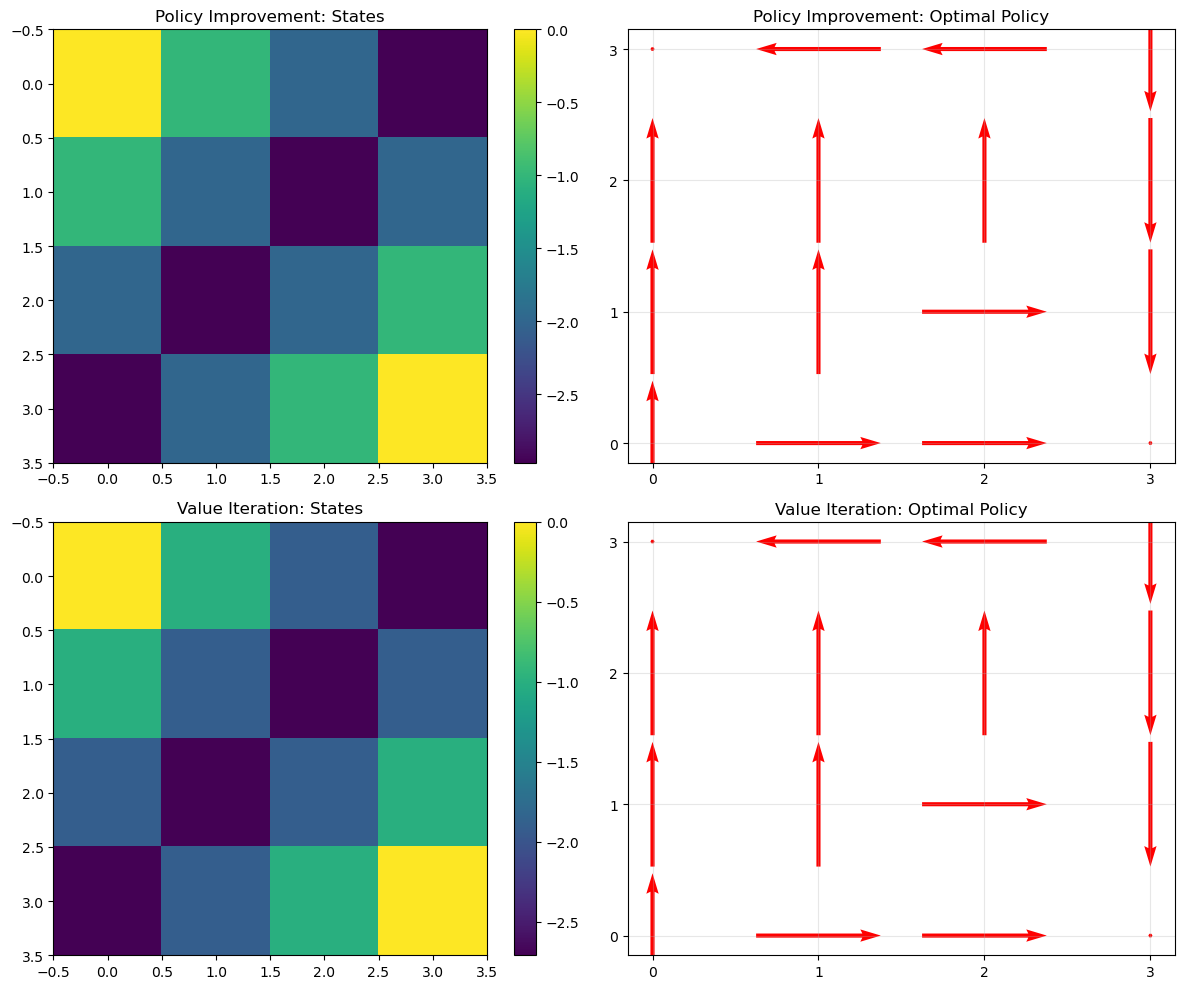

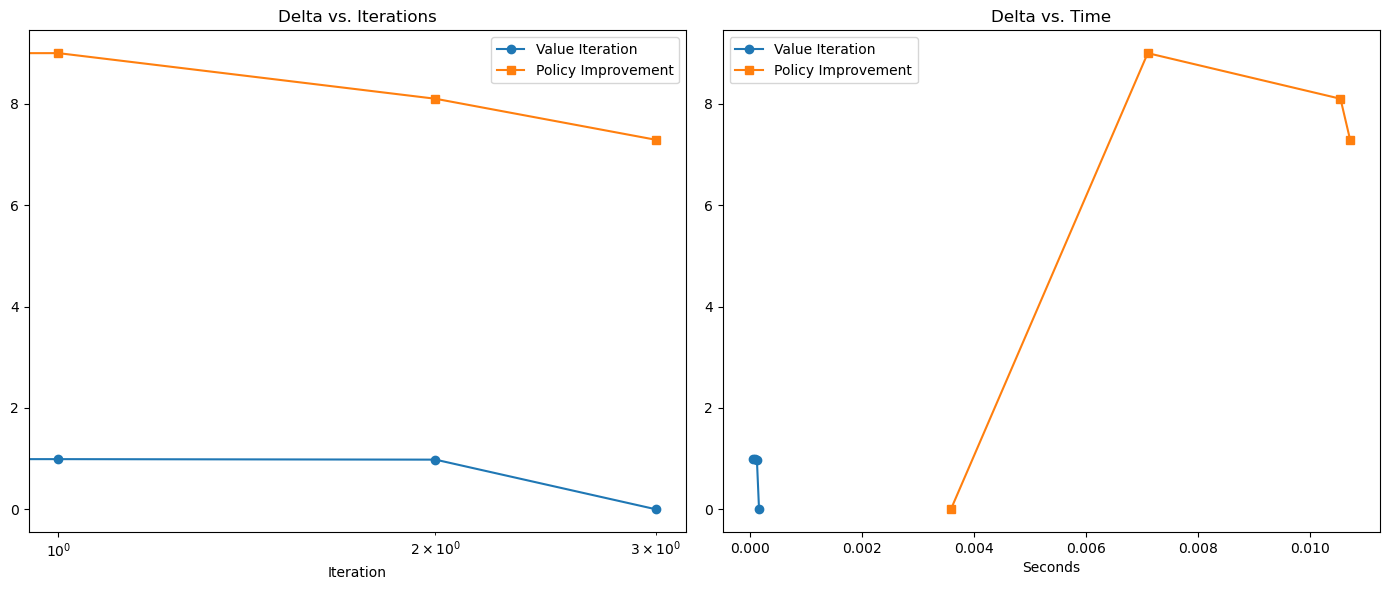

Convergence:
- PI: 3 Iter., 1.07e-02 Sec.
- VI: 3 Iter., 1.67e-04 Sec.


########## Environment (<CustomGridWorld instance>) ##########


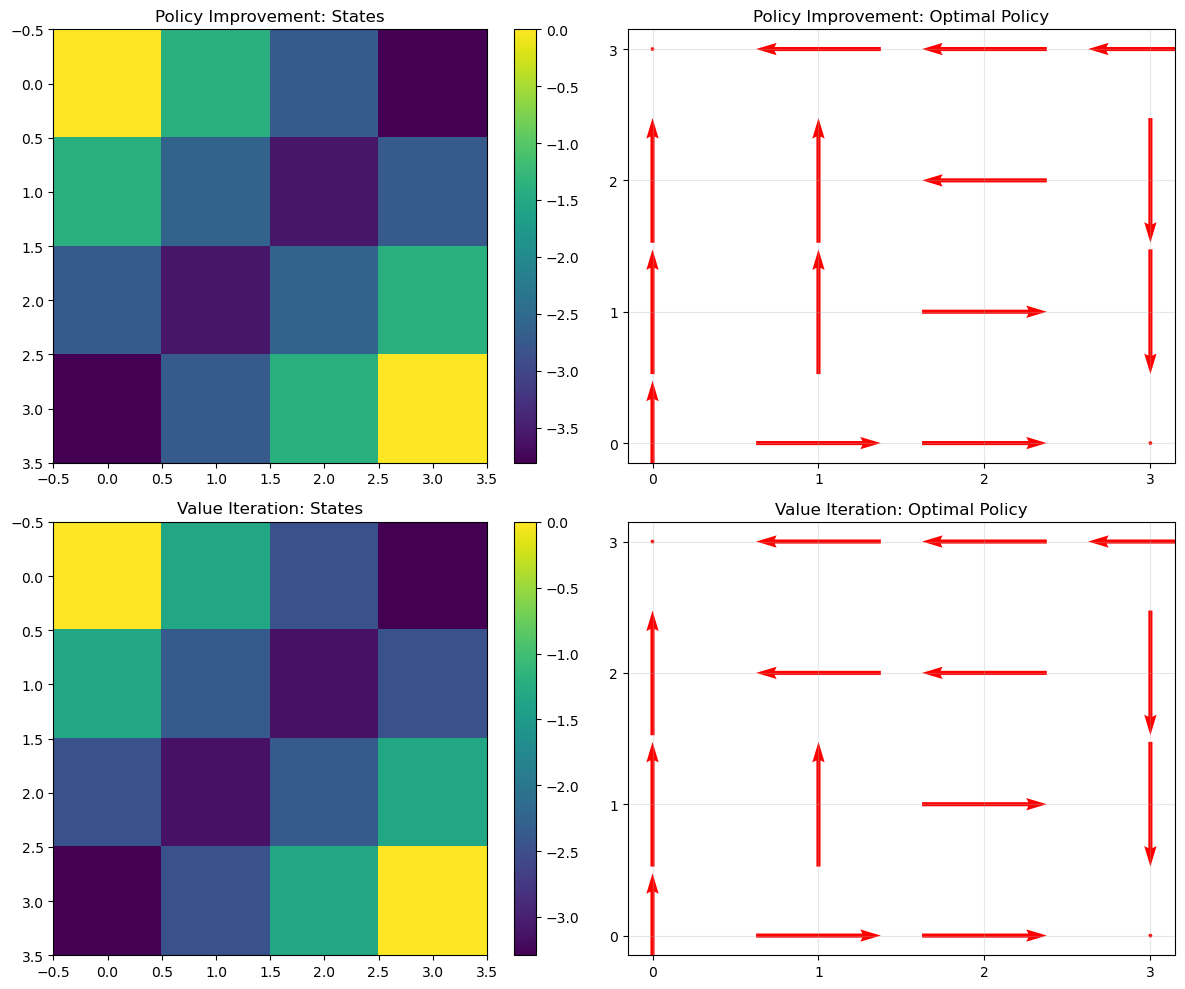

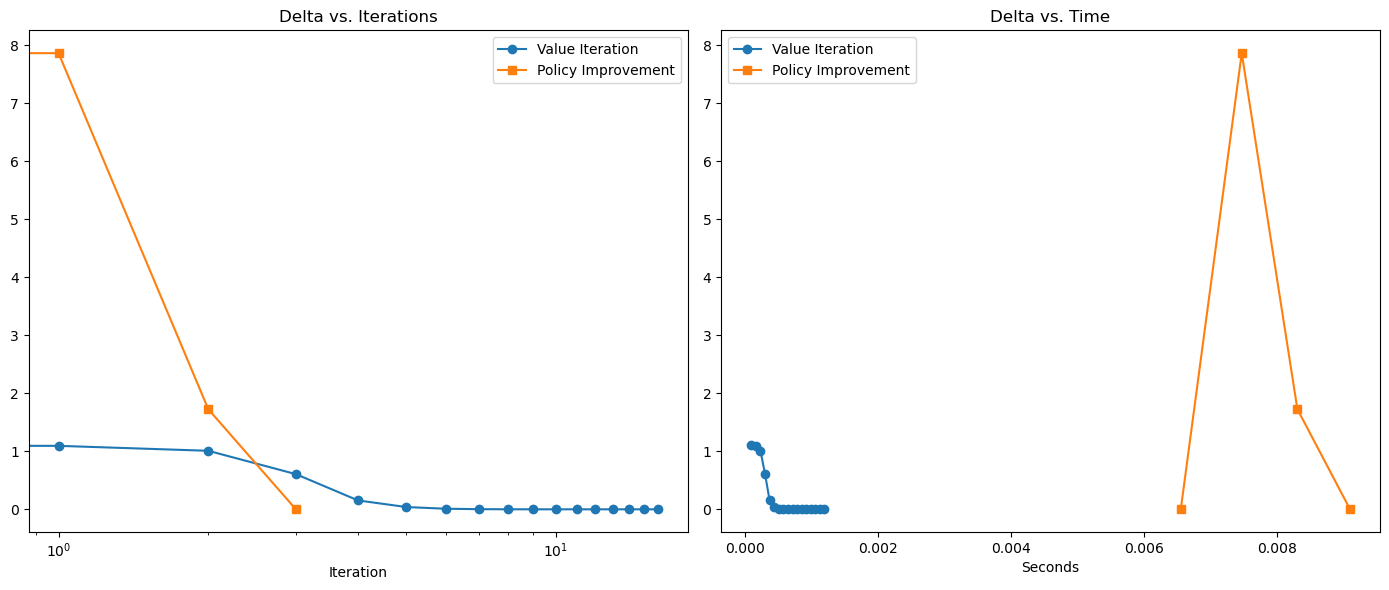

Convergence:
- PI: 3 Iter., 9.10e-03 Sec.
- VI: 16 Iter., 1.18e-03 Sec.


########## Environment (<FrozenLakeEnv<FrozenLake-v1>>) ##########


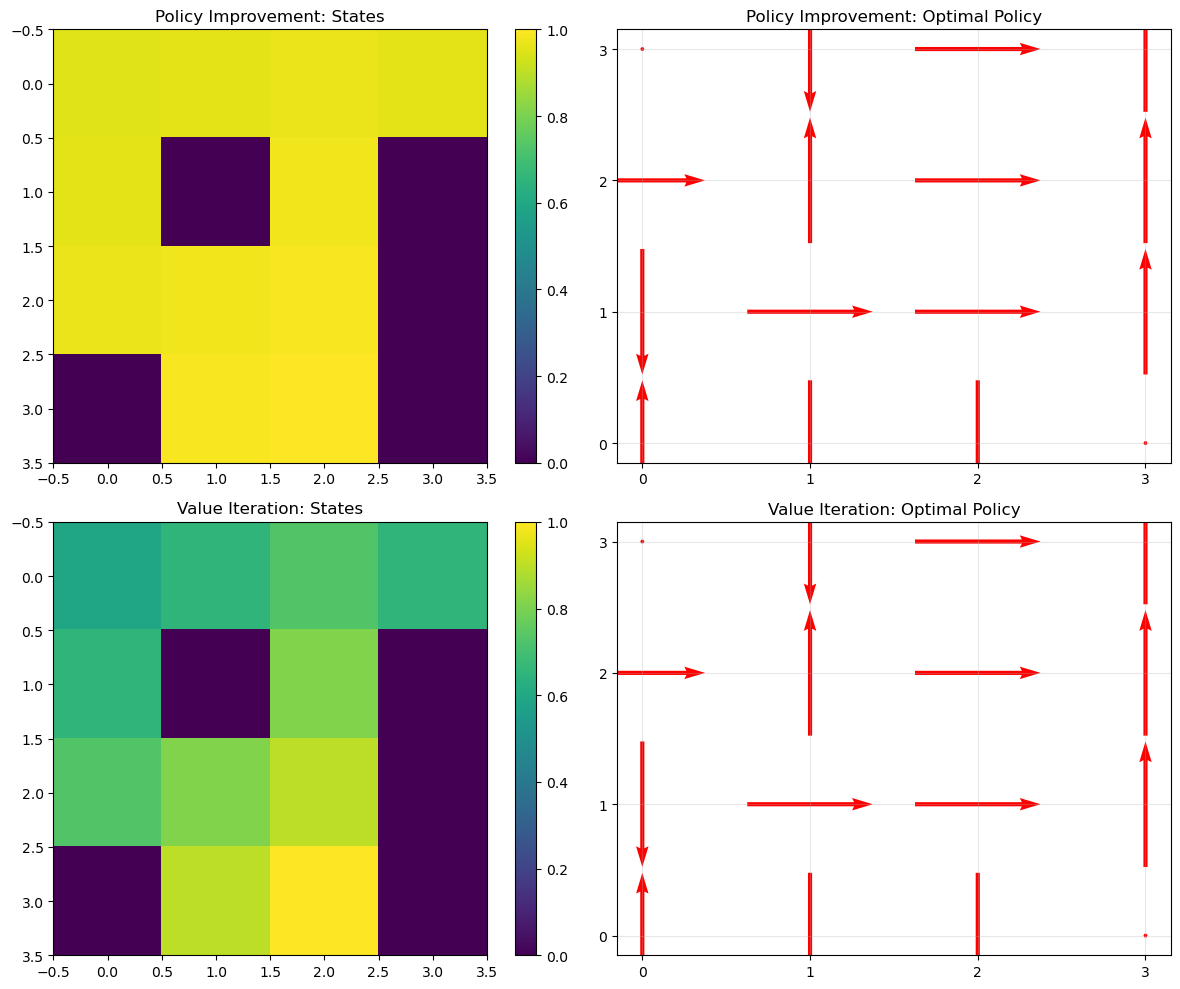

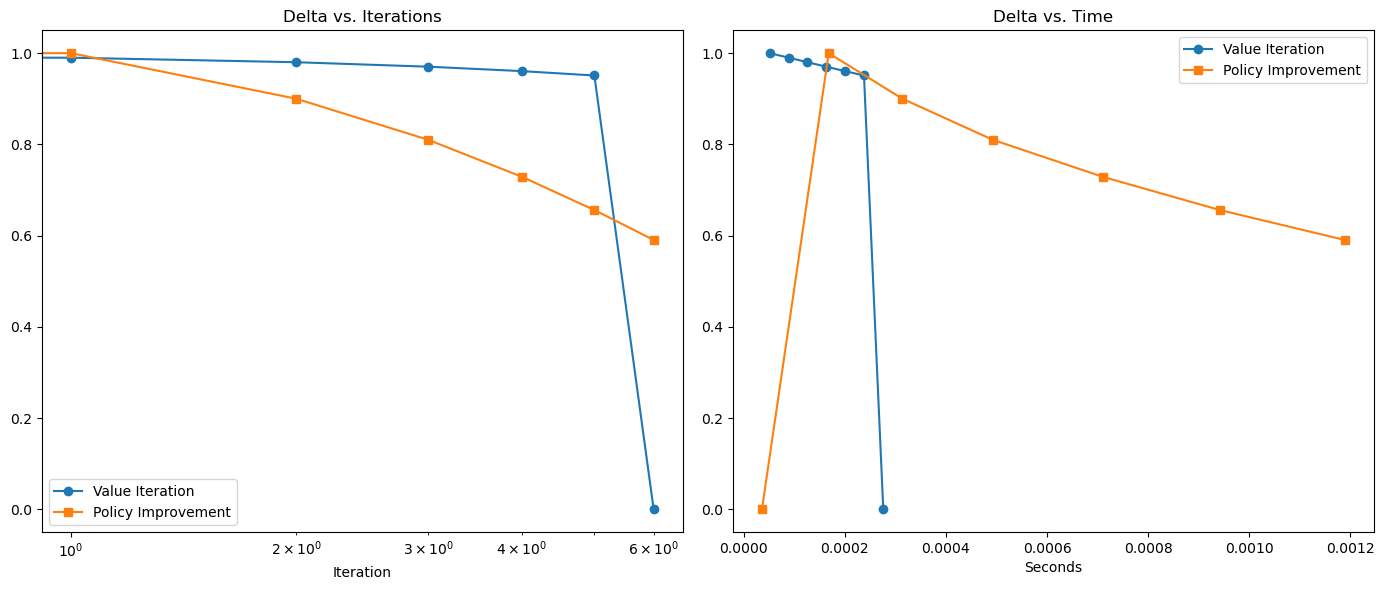

Convergence:
- PI: 6 Iter., 1.19e-03 Sec.
- VI: 6 Iter., 2.76e-04 Sec.


########## Environment (<FrozenLakeEnv<FrozenLake-v1>>) ##########


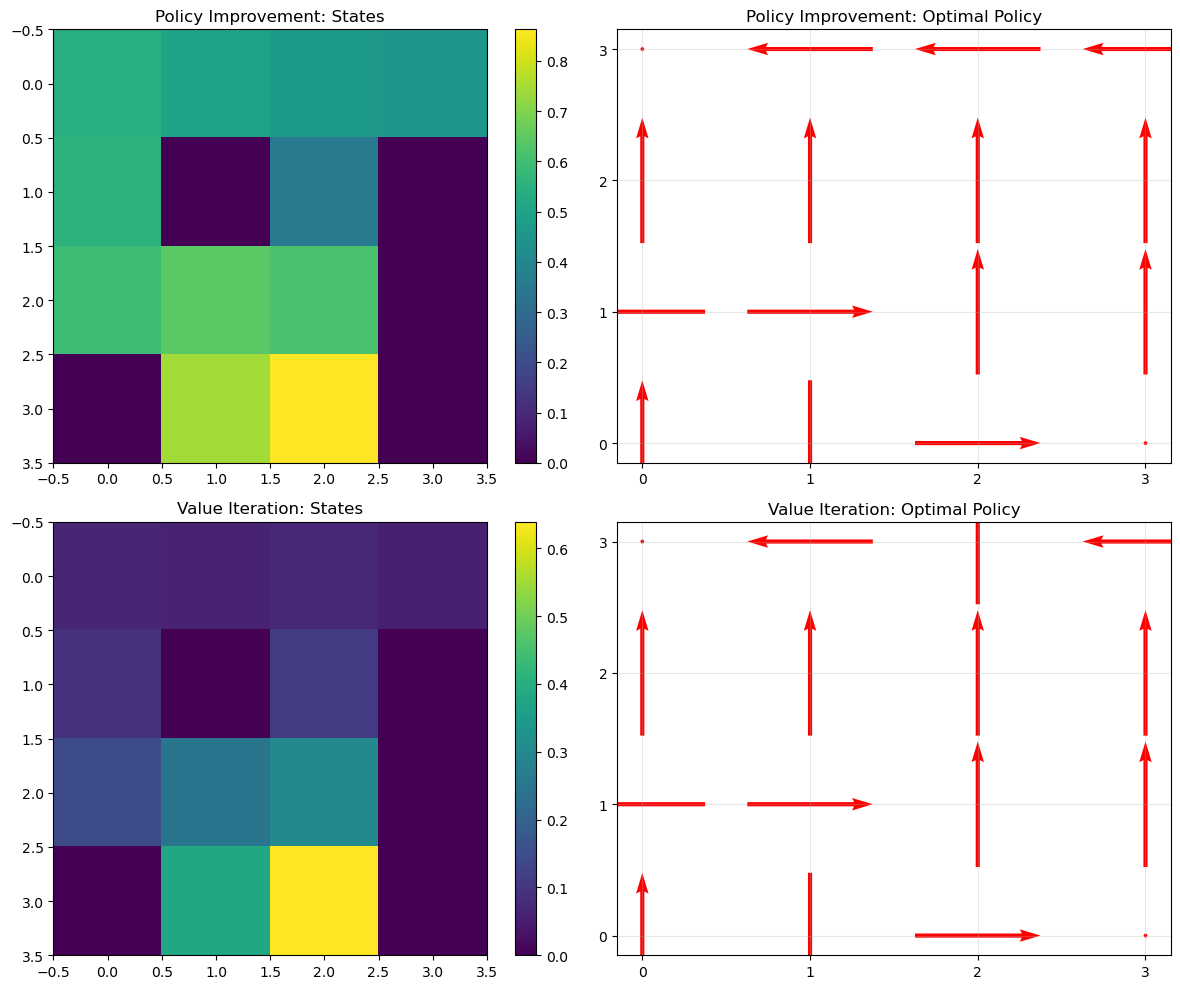

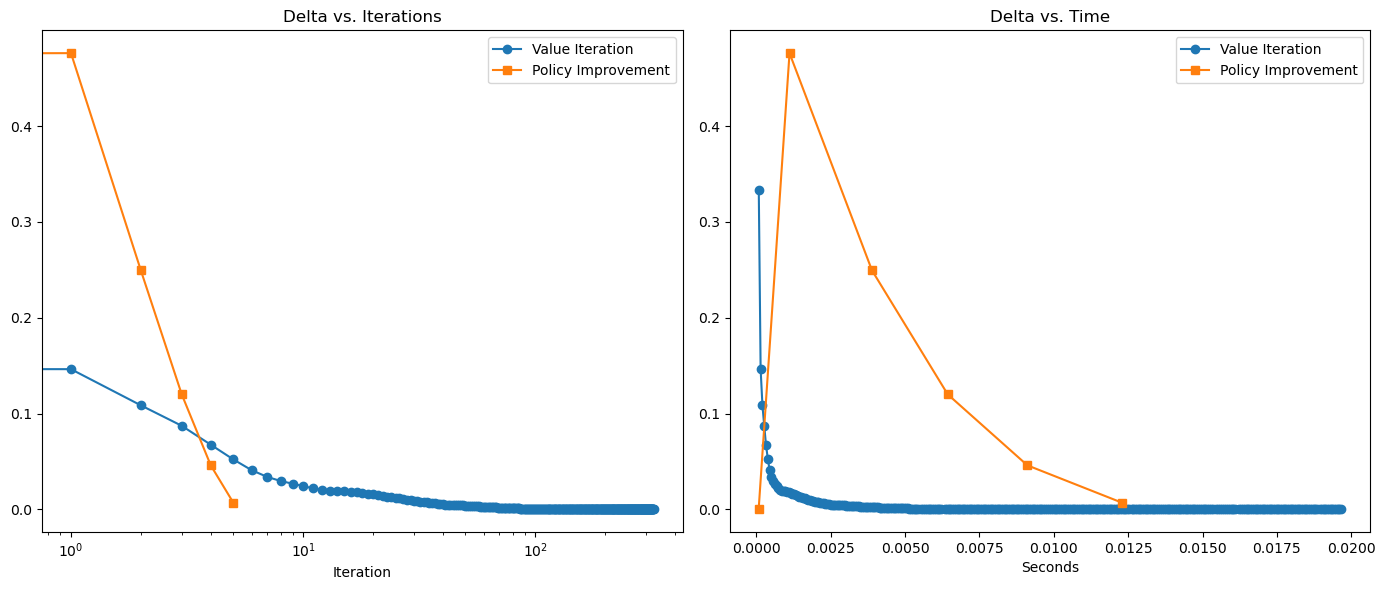

Convergence:
- PI: 5 Iter., 1.23e-02 Sec.
- VI: 323 Iter., 1.97e-02 Sec.




In [2]:
# define environments
env_original = GridWorldOriginal() # original gridworld from instructions
env_custom = CustomGridWorld(size=4, stochasticity=0.2) # stochastic gridworld 80/10/10
lake_sticky = gym.make('FrozenLake-v1', is_slippery=False).unwrapped # no is_slippery for comparison
lake_env = gym.make('FrozenLake-v1', is_slippery=True).unwrapped # is_slippery for stochasticity
lake_nS = lake_env.observation_space.n # extracting for frozenlake 
lake_nA = lake_env.action_space.n

# frozenlake (slippery) p-value:
print('GW original:')
performance_comparison(env_original)
print('\nGW stochastic:')
performance_comparison(env_custom)
print('\nlake sticky:')
performance_comparison(lake_sticky)
print('\nlake slippery:')
performance_comparison(lake_env)
print()

# analyze environments
test_environments = [env_original, env_custom, lake_sticky, lake_env]
for env in test_environments:
    print(f'########## Environment ({env}) ##########')
    policy_pi, V_pi, policy_iters = policy_iteration(env) # policy iteration
    policy_vi, V_vi = value_iteration(env) # value iteration
    
    # visualize
    PI_vals = (policy_pi, V_pi)
    VI_vals = (policy_vi, V_vi)
    plot_results(PI_vals, VI_vals, env)

    pi_max_iter, pi_max_time, vi_max_iter, vi_max_time = analyze_convergence(env=env)
    print('Convergence:')
    print(f'- PI: {pi_max_iter} Iter., {pi_max_time:.2e} Sec.')
    print(f'- VI: {vi_max_iter} Iter., {vi_max_time:.2e} Sec.\n\n')

### results
# GridWorldOriginal: 
# - PI: 3 Iter., 1.07e-02 Sec.
# - VI: 3 Iter., 1.77e-04 Sec.
    
# CustomGridWorld:
# - PI: 2 Iter., 7.92e-03 Sec.
# - VI: 16 Iter., 1.17e-03 Sec.

# frozenlake (slippery): 
# PI: 5 Iter., 1.15e-02 Sec. 
# VI: 323 Iter., 1.90e-02 Sec.

# frozenlake (sticky)
# - PI: 6 Iter., 1.13e-03 Sec.
# - VI: 6 Iter., 2.71e-04 Sec.

### Varying Stochasticity

Stochasticity: 0.0
  - PI 3; 1e-02s
  - VI 3; 3e-04s
Stochasticity: 0.1
  - PI 2; 1e-02s
  - VI 12; 2e-03s
Stochasticity: 0.2
  - PI 3; 9e-03s
  - VI 16; 1e-03s
Stochasticity: 0.3
  - PI 2; 7e-03s
  - VI 22; 1e-03s
Stochasticity: 0.4
  - PI 2; 8e-03s
  - VI 29; 2e-03s
Stochasticity: 0.5
  - PI 3; 9e-03s
  - VI 39; 3e-03s
Stochasticity: 0.6
  - PI 3; 1e-02s
  - VI 54; 4e-03s
Stochasticity: 0.7
  - PI 5; 2e-02s
  - VI 80; 6e-03s
Stochasticity: 0.8
  - PI 4; 2e-02s
  - VI 114; 8e-03s
Stochasticity: 0.9
  - PI 4; 2e-02s
  - VI 111; 8e-03s

Best PI stochasticity value: 0.30000000000000004
Best VI stochasticity value: 0.0


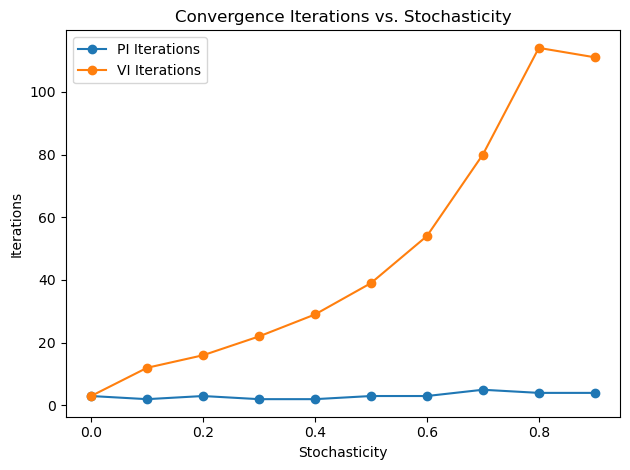

In [3]:
### extra for fun:
# seeing how different stochasticity values effect results
pi_max_times = []
pi_max_iters = []
vi_max_times = []
vi_max_iters = []
test_stochs = np.arange(0.0, 1.0, 0.1)
for i in test_stochs:
    print(f'Stochasticity: {i:.1f}')
    env_temp = CustomGridWorld(size=4, stochasticity=i) # stochastic gridworld 80/10/10
    pi_max_iter, pi_max_time, vi_max_iter, vi_max_time = analyze_convergence(env_temp,verbose=False)
    pi_max_times += [pi_max_time]
    pi_max_iters += [pi_max_iter]
    vi_max_times += [vi_max_time]
    vi_max_iters += [vi_max_iter]
    print(f'  - PI {pi_max_iter}; {pi_max_time:.0e}s\n  - VI {vi_max_iter}; {vi_max_time:.0e}s')
pi_max_times = np.array(pi_max_times)
pi_max_iters = np.array(pi_max_iters)
vi_max_times = np.array(vi_max_times)
vi_max_iters = np.array(vi_max_iters)

pi_best_stochasticity = test_stochs[np.argmin(np.sqrt(pi_max_iters*pi_max_times))]
vi_best_stochasticity = test_stochs[np.argmin(np.sqrt(vi_max_iters*vi_max_times))]
print(f'\nBest PI stochasticity value: {pi_best_stochasticity}')
print(f'Best VI stochasticity value: {vi_best_stochasticity}')

plt.plot(test_stochs, pi_max_iters, label='PI Iterations', marker='o')
plt.plot(test_stochs, vi_max_iters, label='VI Iterations', marker='o')

plt.xlabel('Stochasticity')
plt.ylabel('Iterations')
plt.legend()
plt.title('Convergence Iterations vs. Stochasticity')
plt.tight_layout()
plt.savefig('stochasticity.png')